In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)

In [120]:
df=pd.read_csv("C:/Users/FAISAL/Desktop/dataset/student-por.csv")

In [121]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [122]:
df.shape

(649, 33)

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [124]:
df.isnull().sum().sum()

np.int64(0)

In [125]:
df.duplicated().sum()

np.int64(0)

In [142]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude="object").columns

In [143]:
cat_col

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [144]:
num_col

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

<Axes: xlabel='G3', ylabel='Count'>

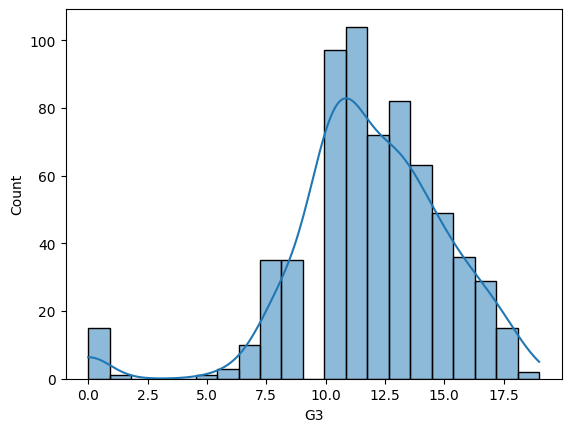

In [129]:
sns.histplot(df['G3'],kde=True)

In [130]:
df[df['G3']==0][['G1','G2','absences','failures']]

,G1,G2,absences,failures
163,11,9,0,2
440,7,0,0,0
519,8,7,0,0
563,7,0,0,1
567,4,0,0,1
583,8,6,0,1
586,8,8,0,0
597,9,0,0,1
603,5,0,0,0
605,5,0,0,1


<Axes: >

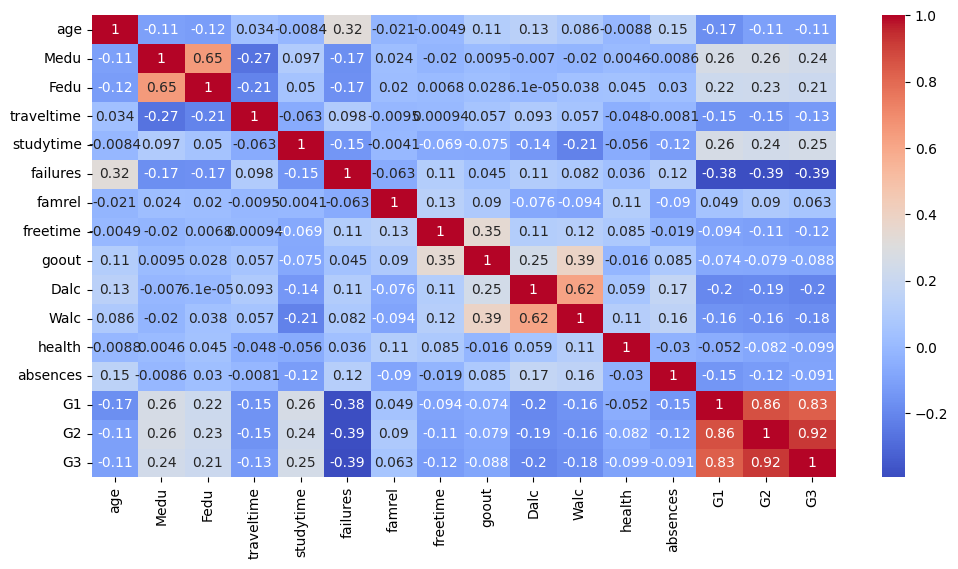

In [131]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

In [132]:
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].unique()}")
    print("-" * 50)

    

school: ['GP' 'MS']
--------------------------------------------------
sex: ['F' 'M']
--------------------------------------------------
address: ['U' 'R']
--------------------------------------------------
famsize: ['GT3' 'LE3']
--------------------------------------------------
Pstatus: ['A' 'T']
--------------------------------------------------
Mjob: ['at_home' 'health' 'other' 'services' 'teacher']
--------------------------------------------------
Fjob: ['teacher' 'other' 'services' 'health' 'at_home']
--------------------------------------------------
reason: ['course' 'other' 'home' 'reputation']
--------------------------------------------------
guardian: ['mother' 'father' 'other']
--------------------------------------------------
schoolsup: ['yes' 'no']
--------------------------------------------------
famsup: ['no' 'yes']
--------------------------------------------------
paid: ['no' 'yes']
--------------------------------------------------
activities: ['no' 'yes']
------

'school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

<Axes: xlabel='school', ylabel='G3'>

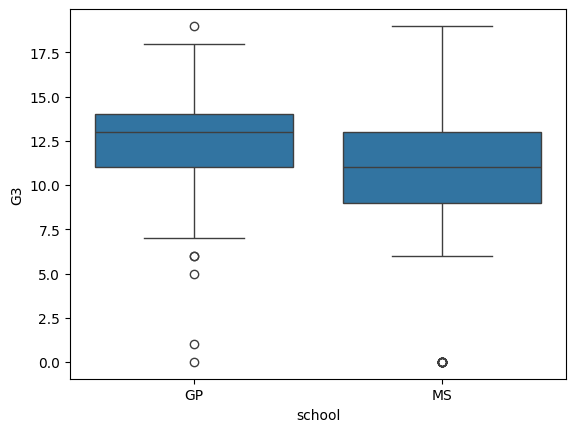

In [133]:
sns.boxplot(data=df,x='school',y='G3')

<Axes: xlabel='nursery', ylabel='G3'>

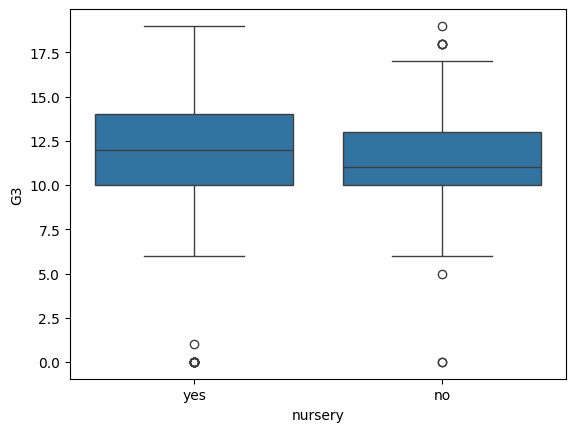

In [134]:
sns.boxplot(data=df,x='nursery',y='G3')

<Axes: xlabel='paid', ylabel='G3'>

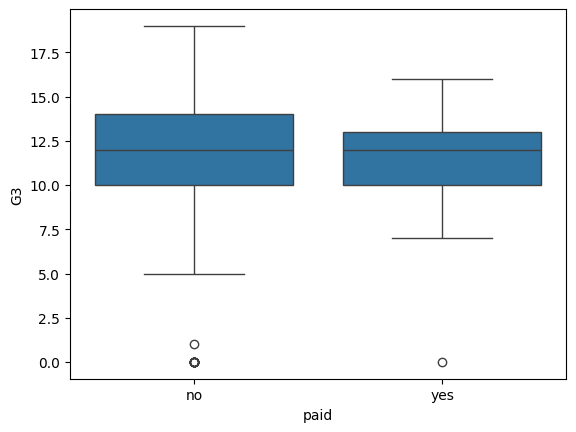

In [135]:
sns.boxplot(data=df,x='paid',y='G3')

In [155]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

In [156]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [157]:
X=df.drop('G3',axis=1)
y=df['G3']
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

In [158]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [159]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [160]:
num_col

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

In [166]:
pipe.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [169]:
y_pred=pipe.predict(X_test)

In [170]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 0.7650597682758259
MSE : 1.4759092563639316
RMSE: 1.2148700573987046
R² Score: 0.8486513286537314


In [171]:
train_score=pipe.score(X_train,y_train)
test_score=pipe.score(X_test,y_test)

In [173]:
print('train_score',train_score)
print('test_score',test_score)

train_score 0.8583369853635902
test_score 0.8486513286537314


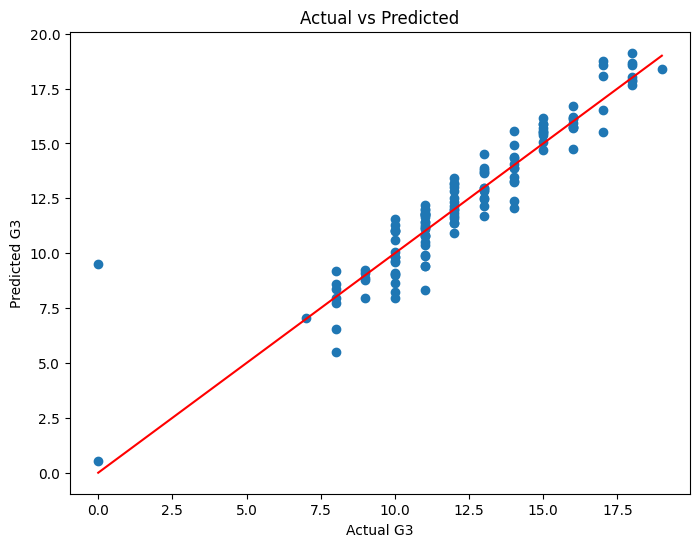

In [176]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted")
plt.show()

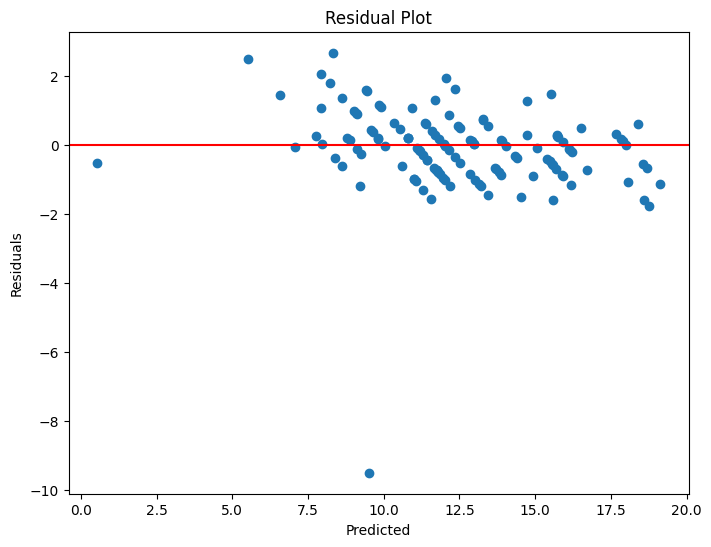

In [177]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [1]:
import joblib
joblib.dump(pipe,'student_performance_model')

NameError: name 'pipe' is not defined